# Predikce rizika diabetu pomocí strojového učení
### Zpracování informací a znalostí
###### 2025/2026  
###### Jména: Petr Dvořák, Duc Anh Tran, Ondřej Hájek, Adam Jandušík, Quang Danh Nguyen   


In [1]:
## Vše co je naformátované v markdown, tak je základ semestrálky a musíme vypracovat jako minimum. 
## V sekcích pro kód dávám vysvětlivky co tam musíme dát. Všechny code komentáře se potom musí smazat!!

## 0 Načtení knihoven a datasetu

In [2]:
## import knihoven
import pandas as pd
import numpy as np
import re
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

## načtení datasetu
df = pd.read_csv("diabetes_dataset.csv")


## 1 Úvod

### 1.1 Byznysový význam
Diabetes patří mezi jednu z nejrozšířenějších civilizačních onemocnění, což představuje tedy významnou zátěž pro zdravotnictví a ekonomiku. Včasná identifikace rizikových pacientů by tedy umožnila preventivní zásahy, které by výrazně snížily náklady na léčbu komplikací spojených s pozdějšími stádii diabetu. Příkladem těchto komplikací může být např. kardiovaskulární onemocnění, selhání ledvin nebo poškození zraku.  

Z pohledu zdravotnictví může model strojového učení pomoci automatizovat předběžné vyhodnocení rizika diabetu na základě dostupných klinických a anamnestických údajů. To umožňuje lékařům soustředit se na pacienty s vyšším rizikem a zefektivnit diagnostický proces. Z pohledu byznysu by model mohl snížit náklady na pozdní léčbu, zvýšit kvalitu péče o pacienty a zlepšit alokaci zdravotnických zdrojů.

### 1.2  Odkaz na zdroj dat
Dataset je dostupný zde:  
https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=diabetes_risk_prediction_dataset&id=46869

## 2  Přizpůsobení dat

### 2.1 Cílový atribut
* Název: class (target)
* Popis: Říká jestli je pacient pozitivně nebo negativně diagnostikován s diabetem

### 2.2 Vybraná instance
* Název:
* Popis:

### 2.3 Atribut zájmu
* Název:
* Popis:

### 2.4 Podmnožina zájmu
* Název:
* Popis:

### 2.5  Matice nákladů

In [3]:
## Matice nákladů by mohla být dána uvedením nákladů na skutečně pozitivní výsledek (1), 
## skutečně negativní výsledek (1), falešně pozitivní výsledek (2) a falešně negativní výsledek (3). 
## Tím se vyjádří, že nejvyšší náklady vzniknou, když klasifikátor předpoví falešně negativní 
## diagnózu (pacient je predikován jako zdravý, ale ve skutečnosti má diabetes).

## 3 Exploratorní analýza dat

### 3.1 Histogram pro cílovou proměnnou

In [4]:
## Zobrazit histogram (nebo tabulku s četnostmi hodnot) pro cílovou proměnnou a pro 
## vybrané další proměnné.

### 3.2 Korelační graf

In [5]:
## Zobrazit graf rozptylu (korelační graf) znázorňující vztah mezi vybranými prediktory a 
## cílovou proměnnou.

### 3.3 Interpretace výsledků

In [6]:
## Bude jen krátký popis podle našich grafů.

## 4 Předzpracování dat

### 4.1 Předzpracování dat pro strojové učení s učitelem

In [7]:
## Petr, Adam, Tom
## a) Rozdělit data na trénovací a testovací
## b) Pokud jsou data nevyvážená tak trénovací soubor buď zvětšit nebo zmenšit pomocí převzorkování
## c) Feature selection - odstranění některých atributů
## Operace z předzpracování nepoužívá informace z testovací sady!!!

## KÓD
df["class"] = df["class"].map({"Positive": 1, "Negative": 0})

dataFrameCommon = df.drop(["Age", "Gender", "class"], axis=1)
featuresCommon = dataFrameCommon.columns

for x in featuresCommon:
    df[x] = df[x].map({'Yes':1, 'No':0})

df["Gender"] = df["Gender"].map({'Male':1,'Female':0})

#Splitting data - modify test size at your leasure, just tell everyone you did it
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2,random_state=42)


## Oversampling cuz it sounds better
negative = train[train["class"] == 0]
positive = train[train["class"] == 1]

negative_overs = negative.sample(
    n=len(positive),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([positive, negative_overs])

### 4.2 Předzpracování dat pro modely bez učitele

In [8]:
## Ondra, David
## a) Odstranit řádky, které nejsou v podskupině
## b) Normalizace třídy věku

## KÓD

## 5 Modelování dat

In [9]:
## Popsat použité parametry

### 5.1 Klasifikační modely

In [10]:
## a) Trénovat model na trénovacích datech a vyhodnotit ho na testovacích datech
## b) Vyzkoušet různé kombinace metaparametrů (např. hloubka stromu, počet stromů v lese atd.) 

#### 5.1.1 Rozhodovací stromy

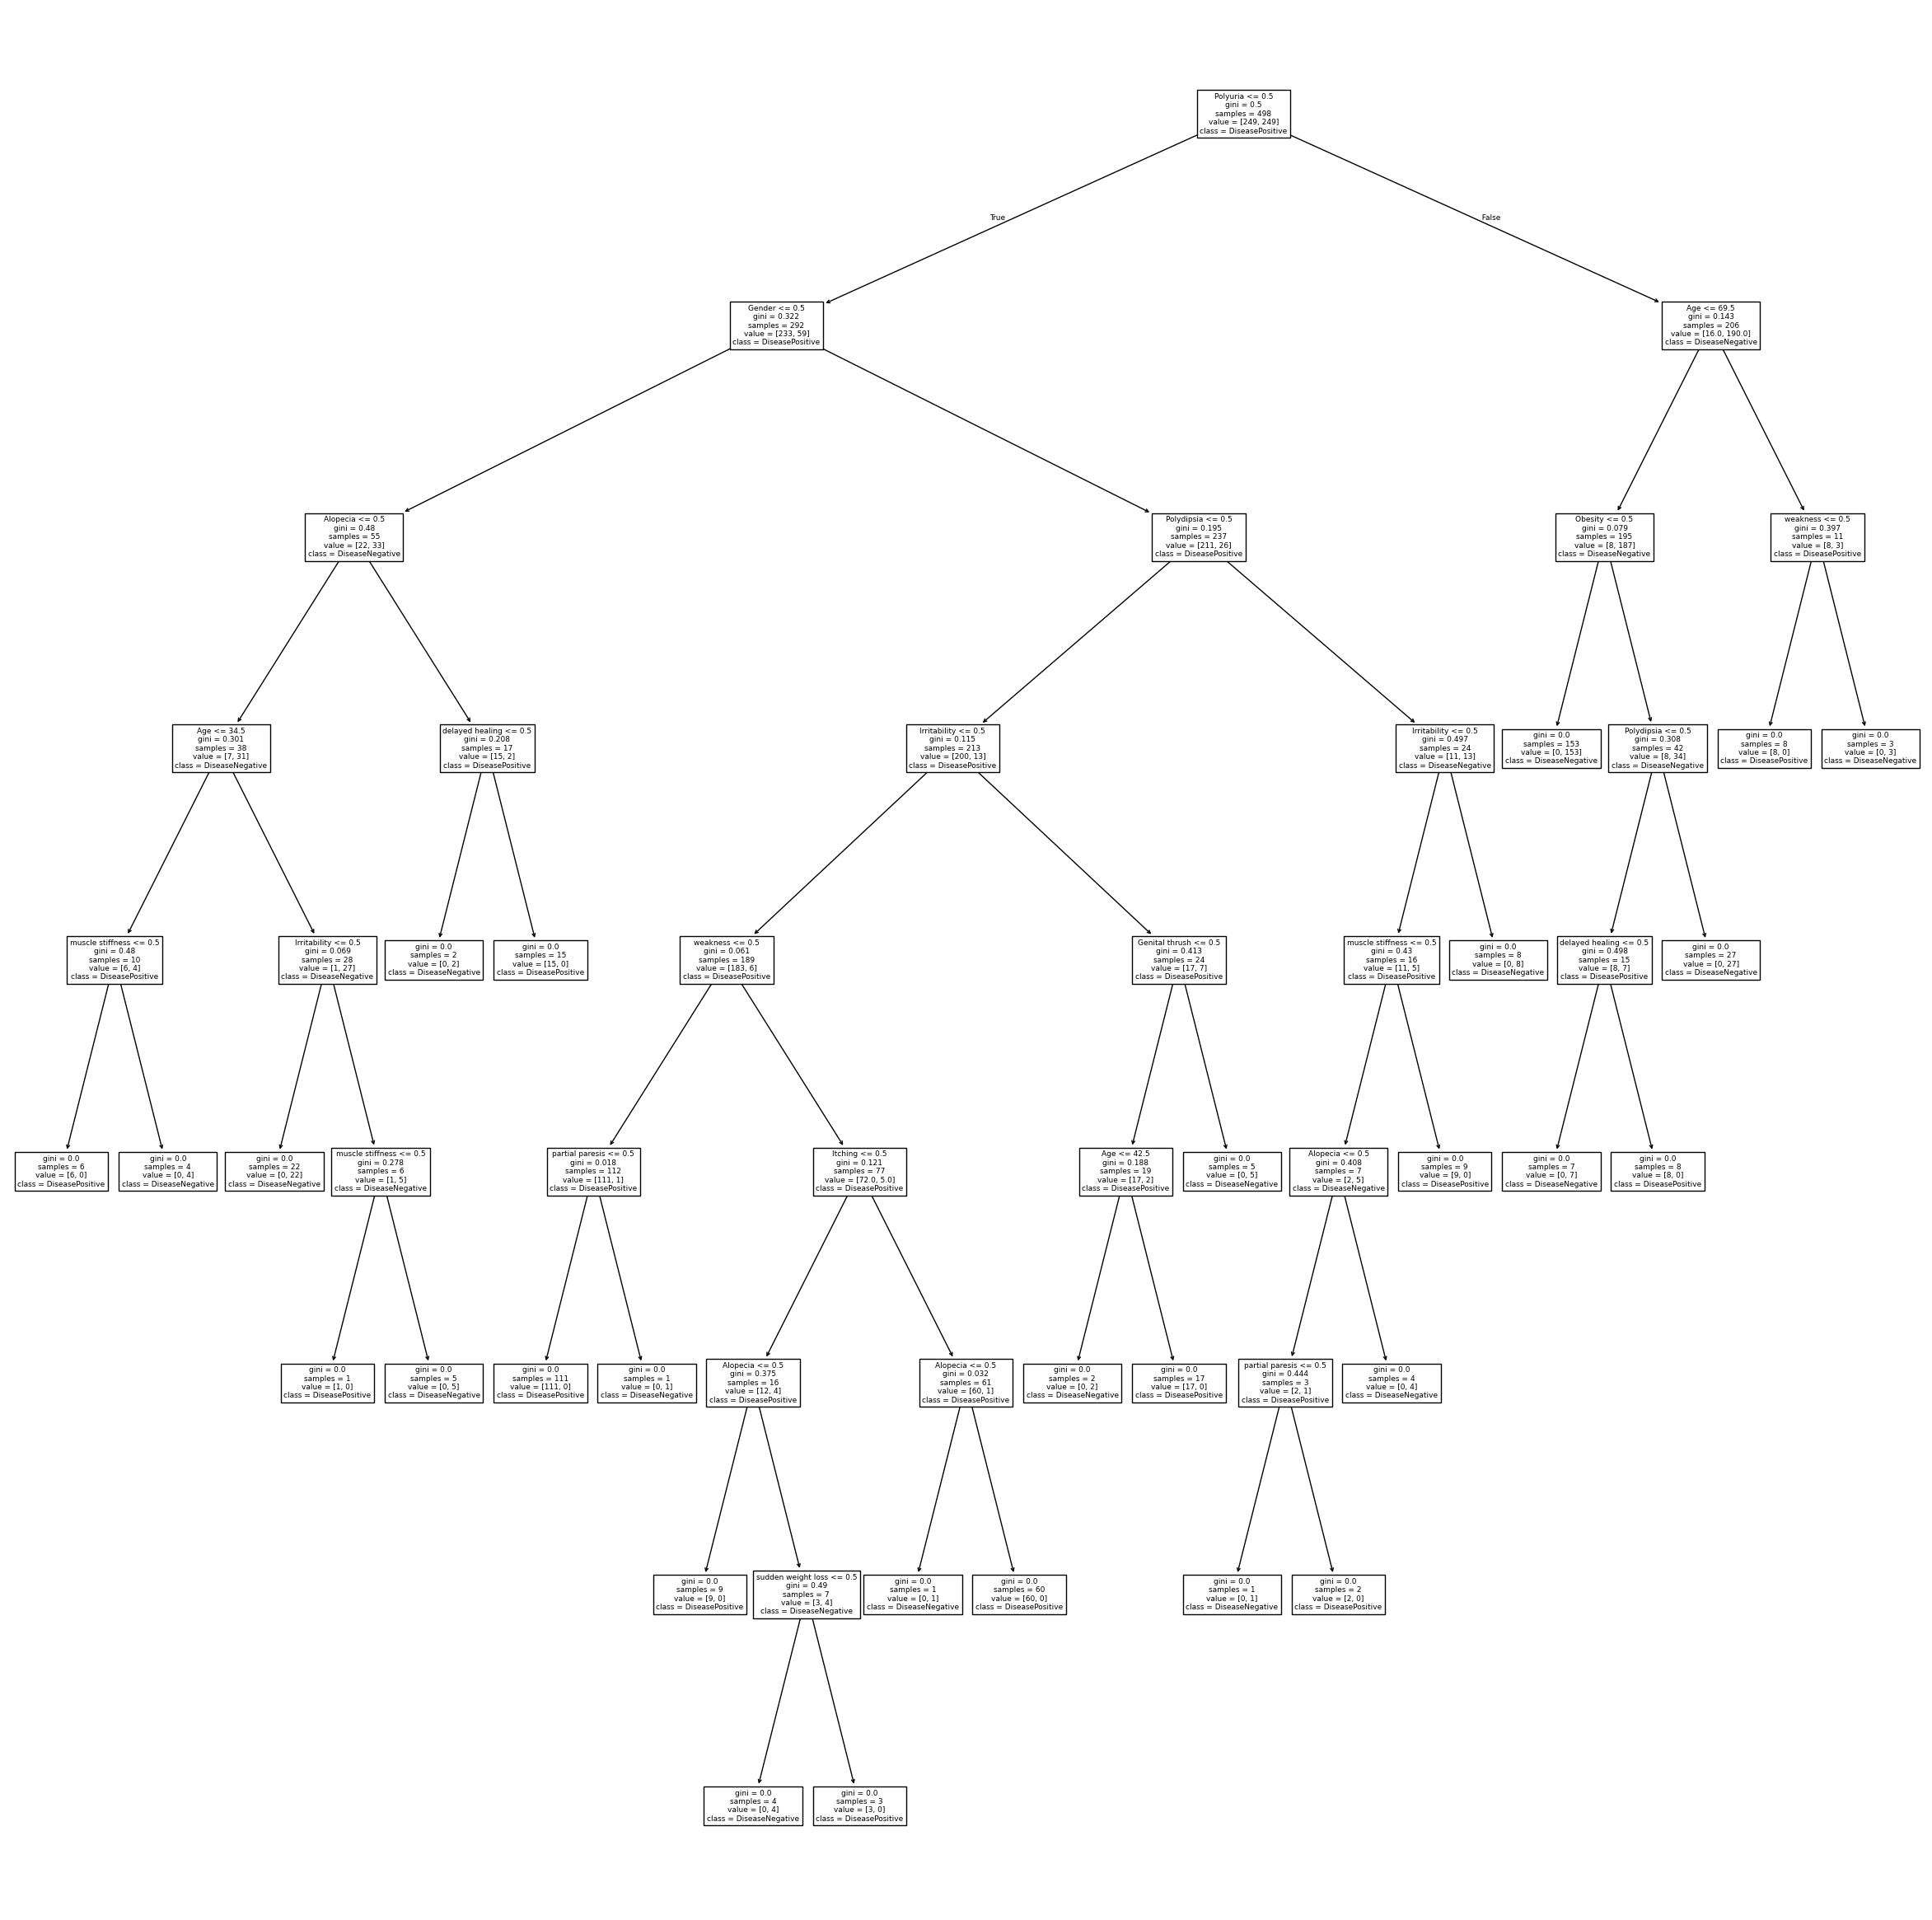

In [11]:
## KÓD
x_train = train_balanced.drop(columns=["class"])
y_train = train_balanced[["class"]]
x_test = test.drop(columns=['class'])
y_test = test[['class']]

decisionTreeClasiffier = DecisionTreeClassifier(random_state=42, max_depth=8)
decisionTreeClasiffier.fit(x_train,y_train)

pred = decisionTreeClasiffier.predict(x_test)
#print(pred)


plt.figure(figsize=(30,30))

dtcClasses=["DiseasePositive","DiseaseNegative"]
x=plot_tree(decisionTreeClasiffier, feature_names=decisionTreeClasiffier.feature_names_in_, class_names=dtcClasses)

## Dvakrát klikněte na strom pro zvětšení

#### 5.1.1 Náhodné lesy

Accuracy: 0.9038461538461539
Precision: 0.9692307692307692
Recall: 0.8873239436619719
F1 score: 0.9264705882352942
Confusion matrix:
[[31  2]
 [ 8 63]]
Classification report:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        33
           1       0.97      0.89      0.93        71

    accuracy                           0.90       104
   macro avg       0.88      0.91      0.89       104
weighted avg       0.91      0.90      0.91       104



,feature,importance
2,Polyuria,0.305694
3,Polydipsia,0.223929
1,Gender,0.104507
4,sudden weight loss,0.090147
12,partial paresis,0.043744
14,Alopecia,0.040810
10,Irritability,0.040419
0,Age,0.035977
8,visual blurring,0.018818
9,Itching,0.016522


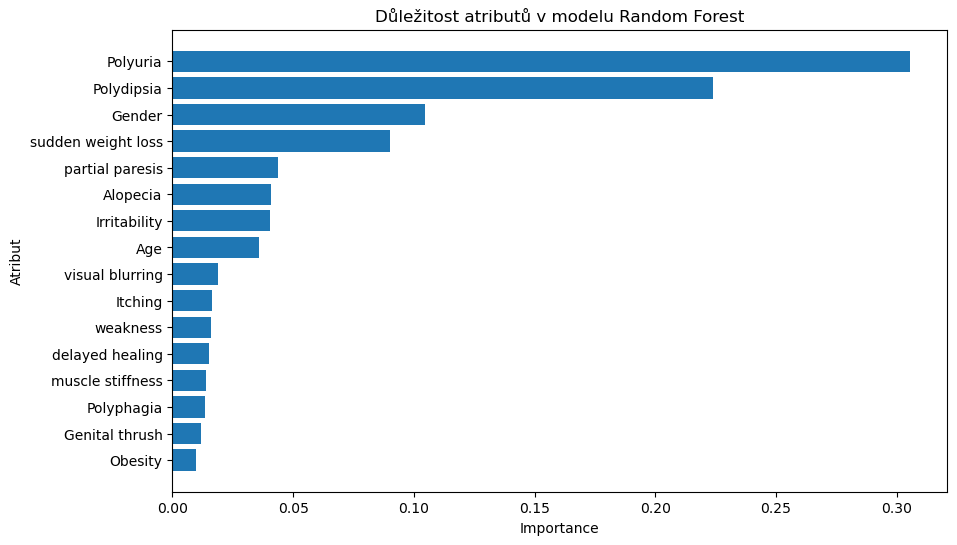

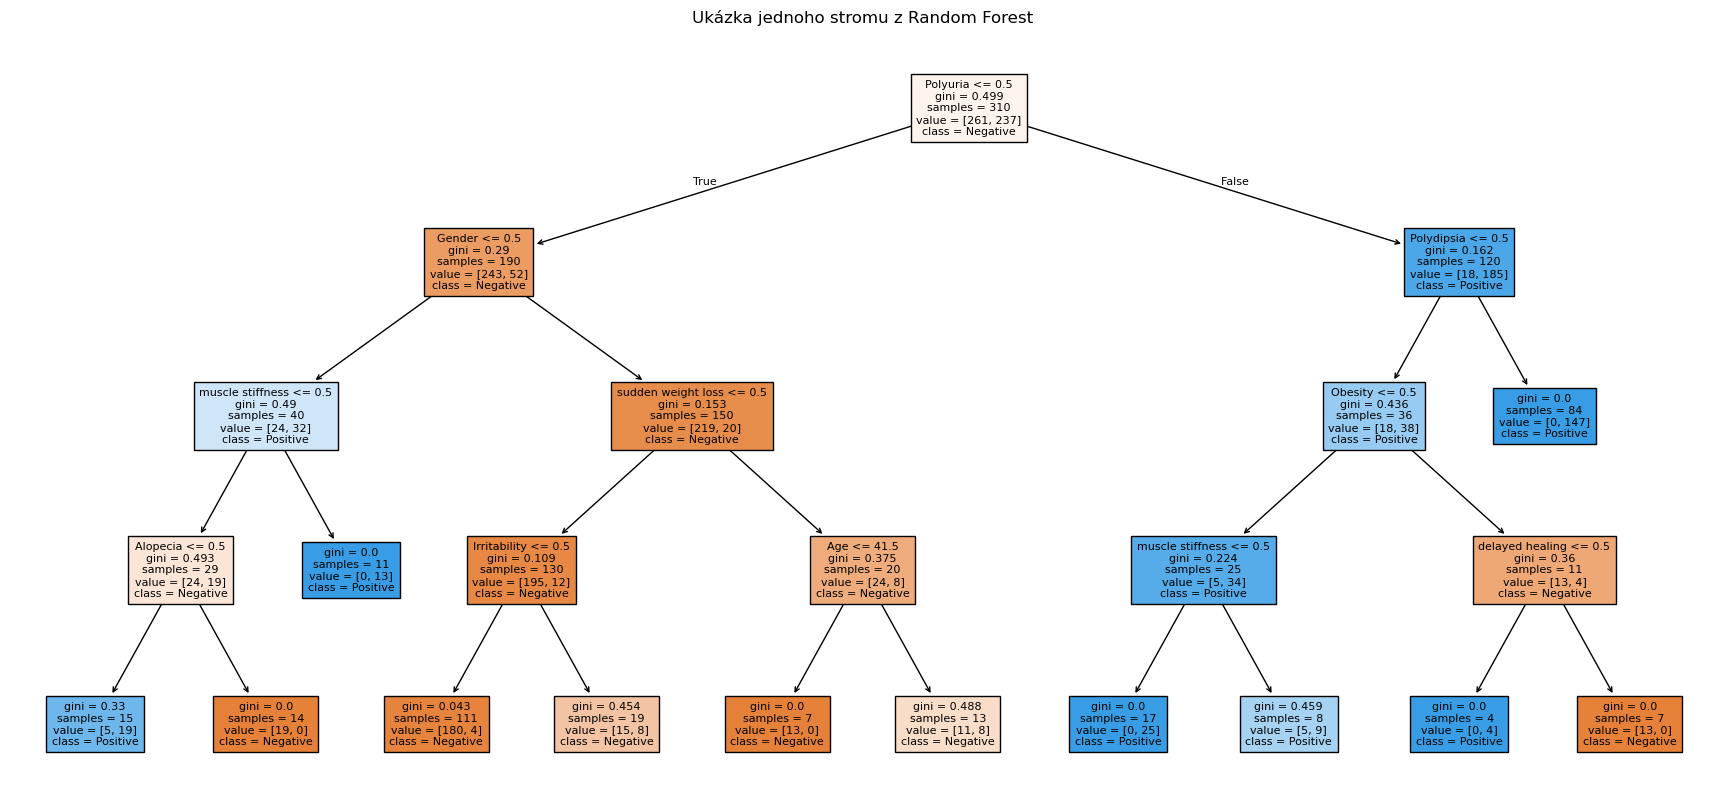

In [21]:
## KÓD

# Random Forest budeme trénovat na stejných datech jako rozhodovací strom,
# aby šlo výsledky férově porovnat.
randomForestClassifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

randomForestClassifier.fit(x_train, y_train.values.ravel())

rf_pred = randomForestClassifier.predict(x_test)
rf_pred_proba = randomForestClassifier.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 score:", f1_score(y_test, rf_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_pred))
print("Classification report:")
print(classification_report(y_test, rf_pred))

# Důležitost atributů
rf_importance_df = pd.DataFrame({
    "feature": x_train.columns,
    "importance": randomForestClassifier.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance_df["feature"], rf_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Důležitost atributů v modelu Random Forest")
plt.xlabel("Importance")
plt.ylabel("Atribut")
plt.show()

# Ukázka jednoho stromu z lesa
first_tree = randomForestClassifier.estimators_[0]

plt.figure(figsize=(22, 10))
plot_tree(
    first_tree,
    feature_names=x_train.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    max_depth=4,
    fontsize=8
)
plt.title("Ukázka jednoho stromu z Random Forest")
plt.show()


### 5.2 Shlukovací modely

In [13]:
## a) Vyzkoušet různá nastavení shlukování
## b) Vyzkoušet různá nastavení metaparametrů (např. pošet shluků pro k-means)
## c) Vybrat nejvhodnější hodnotu

#### 5.2.1 Ploché shlukování

In [14]:
## KÓD

#### 5.2.2 Hierarchické shlukování

In [15]:
## KÓD

## 6 Evaluace

### 6.1 Klasifikační model

In [16]:
## a) Vybereme metriku F1 score, protože chceme rozumný kompromis mezi precision a recall.
##    Ve zdravotním kontextu je důležité zachytit pozitivní případy, ale nechceme ani příliš mnoho
##    falešných poplachů.

# Predikce rozhodovacího stromu
dt_pred = decisionTreeClasiffier.predict(x_test)

# Tabulka metrik pro oba modely
evaluation_df = pd.DataFrame([
    {
        "model": "Decision Tree",
        "accuracy": accuracy_score(y_test, dt_pred),
        "precision": precision_score(y_test, dt_pred),
        "recall": recall_score(y_test, dt_pred),
        "f1_score": f1_score(y_test, dt_pred)
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision": precision_score(y_test, rf_pred),
        "recall": recall_score(y_test, rf_pred),
        "f1_score": f1_score(y_test, rf_pred)
    }
])

display(evaluation_df.sort_values("f1_score", ascending=False))

print("Confusion matrix - Decision Tree")
print(confusion_matrix(y_test, dt_pred))

print("\nConfusion matrix - Random Forest")
print(confusion_matrix(y_test, rf_pred))


,model,accuracy,precision,recall,f1_score
0,Decision Tree,0.980769,1.000000,0.971831,0.985714
1,Random Forest,0.903846,0.969231,0.887324,0.926471


Confusion matrix - Decision Tree
[[33  0]
 [ 2 69]]

Confusion matrix - Random Forest
[[31  2]
 [ 8 63]]


### 6.2 Shlukování

In [17]:
## a) Zdůvodnit zvolené k (počet shluků) pomocí grafu loketní křivky WCSS nebo Silhouette score
## b) Vyhodnocení kvality shlukování pomocí některé z interních nebo externích metrik

## 7 Interpretace dat

### 7.1 Klasifikace

In [18]:
## Interpretace klasifikačních modelů

# 1) Nejdůležitější atributy z Random Forest
display(rf_importance_df.head(10))

# 2) Vybraná instance z testovacích dat
selected_instance = x_test.iloc[[0]]

dt_instance_pred = decisionTreeClasiffier.predict(selected_instance)[0]
dt_instance_proba = decisionTreeClasiffier.predict_proba(selected_instance)[0]

rf_instance_pred = randomForestClassifier.predict(selected_instance)[0]
rf_instance_proba = randomForestClassifier.predict_proba(selected_instance)[0]

print("Vybraná instance:")
display(selected_instance)

print("Decision Tree predikce:", dt_instance_pred)
print("Decision Tree pravděpodobnosti [Negative, Positive]:", dt_instance_proba)

print("Random Forest predikce:", rf_instance_pred)
print("Random Forest pravděpodobnosti [Negative, Positive]:", rf_instance_proba)

# 3) Jednoduchá slovní interpretace
print("\nInterpretace:")
print("Random Forest obvykle poskytuje stabilnější predikce než jeden strom,")
print("protože kombinuje více stromů a omezuje vliv náhodných odchylek v datech.")
print("Atributy s nejvyšší importance mají největší vliv na konečné rozhodnutí modelu.")


,feature,importance
2,Polyuria,0.305694
3,Polydipsia,0.223929
1,Gender,0.104507
4,sudden weight loss,0.090147
12,partial paresis,0.043744
14,Alopecia,0.040810
10,Irritability,0.040419
0,Age,0.035977
8,visual blurring,0.018818
9,Itching,0.016522


Vybraná instance:


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
275,72,1,1,0,0,0,1,0,1,1,0,1,1,1,1,0


Decision Tree predikce: 0
Decision Tree pravděpodobnosti [Negative, Positive]: [1. 0.]
Random Forest predikce: 0
Random Forest pravděpodobnosti [Negative, Positive]: [0.72340217 0.27659783]

Interpretace:
Random Forest obvykle poskytuje stabilnější predikce než jeden strom,
protože kombinuje více stromů a omezuje vliv náhodných odchylek v datech.
Atributy s nejvyšší importance mají největší vliv na konečné rozhodnutí modelu.


### 7.2 Shlukování

In [19]:
## a) Interpretovat konečné shluky na základě jejich centroidů a počtu instancí v každém shluku
## b) Pomocí modelu dosadit vybranou instanci do shluku a zkontrolovat přiřazený shluk
## c) Shoduje se hodnota cílové třídy v datech s nejčastější třídou v přiřazeném shluku (nepovinné)?

## 8 Závěr

In [20]:
## Závěr by měl být jen textový
## Shrnout výsledky a odpovědět na následující otázky:
## 1. Který výsledek strojového učení má nejvyšší hodnotu a je nejzajímavější? 
## 2. Jaké nastavení poskytlo nejlepší výsledek? 
## 3. Které atributy jsou nejdůležitější?


# Závěrečný kontrolní seznam 

* Jsou všechny kroky předzpracování zdůvodněné?
* Vyzkoušeli jste různé hodnoty metaparametrů modelovacích algoritmů?
* Jsou výsledky opakovatelné? Pokud máte k dispozici stejná data, popisuje zpráva všechny kroky dostatečně podrobně, abyste získali stejné výsledky?
* Byly zvoleny správné hodnotící metriky? Jsou výsledky správně interpretovány?
* Jsou všechny důležité kroky vysvětleny a zdůvodněny?
* Jaká je kvalita textu? Je jazyk jasný a stručný?

# SMAZAT TUTO BUŇKU NA KONCI!!!
